In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import omicverse as ov
#import scvi
#from scvi.model.utils import mde
#from scarches.dataset.trvae.data_handling import remove_sparsity
from scipy import sparse

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel fro

In [2]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (3, 3)

In [3]:
adata1 = sc.read('/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251021_fetal_adult_brain_merge_rename_scdevelopment/data/All_non-neuronal_cells.h5ad')
adata2 = sc.read('/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251021_fetal_adult_brain_merge_rename_scdevelopment/data/All_neurons.h5ad')

In [4]:
def preprocess_gene_names_keep_first(adata):
    """处理基因名，用feature_name替换，对重复基因保留第一个出现的"""
    # 保存原始基因名到新的列
    adata.var['original_gene_id'] = adata.var.index
    
    # 获取feature_name
    feature_names = adata.var['feature_name'].values
    
    # 创建临时DataFrame来处理重复基因
    temp_df = pd.DataFrame({
        'feature_name': feature_names,
        'original_index': range(len(feature_names))
    })
    
    # 找出第一个出现的唯一基因
    unique_indices = temp_df.drop_duplicates(subset='feature_name', keep='first').index
    
    # 筛选出唯一的基因
    adata_unique = adata[:, unique_indices].copy()
    
    # 设置新的索引为feature_name
    adata_unique.var.index = adata_unique.var['feature_name'].values
    
    print(f"原始基因数: {adata.n_vars}")
    print(f"去重后基因数: {adata_unique.n_vars}")
    print(f"移除的重复基因数: {adata.n_vars - adata_unique.n_vars}")
    
    return adata_unique

# 处理第一个数据集
print("处理 adata1...")
adata1 = preprocess_gene_names_keep_first(adata1)

# 处理第二个数据集
print("\n处理 adata2...")
adata2 = preprocess_gene_names_keep_first(adata2)

处理 adata1...
原始基因数: 59236
去重后基因数: 58032
移除的重复基因数: 1204

处理 adata2...
原始基因数: 59236
去重后基因数: 58032
移除的重复基因数: 1204


In [5]:
import scanpy as sc
import anndata as ad

# 合并数据
combined_adata = ad.concat(
    {"non-neuronal": adata1, "All_neurons": adata2},
    label="batch",  # 添加批次信息列
    join="inner"  # 保留共有的基因
)

print(f"合并后的数据形状: {combined_adata.shape}")

合并后的数据形状: (3369219, 58032)


In [6]:
xlsx_path = "/storage2/liuxiaodongLab/fanxueying/developmental_atlas/code/20251105_human_adult_brain_data_prep/science.add7046_table_s3.xlsx"
annotation_df = pd.read_excel(xlsx_path)

In [7]:
mask = (
    annotation_df['Class auto-annotation'].isna() &
    annotation_df['Neurotransmitter auto-annotation'].notna()
)
annotation_df.loc[mask, 'Class auto-annotation'] = 'NEUR'

In [8]:
def float_to_id(x):
    if pd.isna(x):
        return ""
    return str(int(x))  # safely convert 50.0 → "50"

annotation_df['Cluster ID'] = annotation_df['Cluster ID'].apply(float_to_id)

# Set index
annotation_df = annotation_df.set_index('Cluster ID')

In [40]:
combined_adata

AnnData object with n_obs × n_vars = 3369219 × 58032
    obs: 'ROIGroup', 'ROIGroupCoarse', 'ROIGroupFine', 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'batch'
    obsm: 'X_UMAP', 'X_tSNE'

In [9]:
def clean_cluster_id(x):
    if pd.isna(x):
        return ""
    # Handle both string "50", int 50, float 50.0
    try:
        return str(int(float(x)))
    except (ValueError, TypeError):
        return str(x).strip()

cluster_ids = combined_adata.obs['cluster_id'].apply(clean_cluster_id)

# Map
combined_adata.obs['Supercluster'] = cluster_ids.map(annotation_df['Supercluster'])
combined_adata.obs['Class_auto_annotation'] = cluster_ids.map(annotation_df['Class auto-annotation'])
combined_adata.obs['Neurotransmitter auto-annotation'] = cluster_ids.map(annotation_df['Neurotransmitter auto-annotation'])

# Fill missing
combined_adata.obs['Supercluster'].fillna("Unknown", inplace=True)
combined_adata.obs['Class_auto_annotation'].fillna("Unknown", inplace=True)
combined_adata.obs['Neurotransmitter auto-annotation'].fillna("Unknown", inplace=True)

In [ ]:
# Check first few rows
print(combined_adata.obs[['cluster_id', 'Supercluster', 'Class_auto_annotation']].head(10))

# Check unique values
print(combined_adata.obs['Supercluster'].value_counts(dropna=False))

In [ ]:
print(combined_adata.obs['Class_auto_annotation'].value_counts(dropna=False))
print(combined_adata.obs['Neurotransmitter auto-annotation'].value_counts(dropna=False))

In [10]:
rename_map = {
    'NEUR': 'Neuron',
    'OLIGO': 'Oligo',
    'ASTRO': 'Astrocyte',
    'OPC': 'OPC',
    'MGL': 'Microglia',
    'MAC': 'Microglia',          # ← corrected typo
    'CHRP': 'Choroid plexus',
    'FIB': 'Fibroblast',
    'ENDO': 'Endothelial',
    'PER': 'Pericyte',
    'EPEN': 'Ependymal',
    'TCELL': 'T cell',
    'NK': 'NK cell',
    'MONO': 'Monocyte',
    'VSMC': 'Vascular smooth muscle',
    'BCELL': 'B cell',
    'CHRP NEUR': 'Neuron',
    'CHRP EPEN': 'Ependymal',
    'ENDO VSMC': 'Vascular',
    'CHRP ENDO': 'Vascular',
    'CHRP EPEN OLIGO': 'Choroid plexus',
    'CHRP EPEN NEUR': 'OPC',  # based on original definition:Committed oligodendrocyte precursor
}

# Create a new column with updated names
combined_adata.obs['cell_class'] = combined_adata.obs['Class_auto_annotation'].map(rename_map).fillna(combined_adata.obs['Class_auto_annotation'])

In [ ]:
# Check unique values
print(combined_adata.obs['cell_class'].value_counts(dropna=False))

In [11]:
# 2. Now define immune and vascular groups (after cleaning)
immune_types = {'T cell', 'NK cell', 'B cell', 'Monocyte'}
vascular_types = {'Endothelial', 'Vascular smooth muscle', 'Pericyte', 'Vascular'}  # include 'Vascular'

# 3. Assign lineage
def assign_lineage(cell_type):
    if cell_type in immune_types:
        return 'Immune'
    elif cell_type in vascular_types:
        return 'Vascular'
    else:
        return cell_type

combined_adata.obs['lineage'] = combined_adata.obs['cell_class'].apply(assign_lineage)

In [ ]:
# Check unique values
print(combined_adata.obs['lineage'].value_counts(dropna=False))

In [12]:
# Ensure cluster_id is string (to match your obs index type)
combined_adata.obs['cluster_id_str'] = combined_adata.obs['cluster_id'].astype(str)

# Create a copy of current lineage (or overwrite directly)
combined_adata.obs['lineage_corrected'] = combined_adata.obs['lineage'].copy()

# Override specific clusters
combined_adata.obs.loc[combined_adata.obs['cluster_id_str'] == '23', 'lineage_corrected'] = 'Vascular'
combined_adata.obs.loc[combined_adata.obs['cluster_id_str'] == '29', 'lineage_corrected'] = 'Fibroblast'

# replace the original 'lineage' column
combined_adata.obs['lineage'] = combined_adata.obs['lineage_corrected']
del combined_adata.obs['lineage_corrected']
del combined_adata.obs['cluster_id_str']  # clean up

'lineage' is not categorical — no action needed.


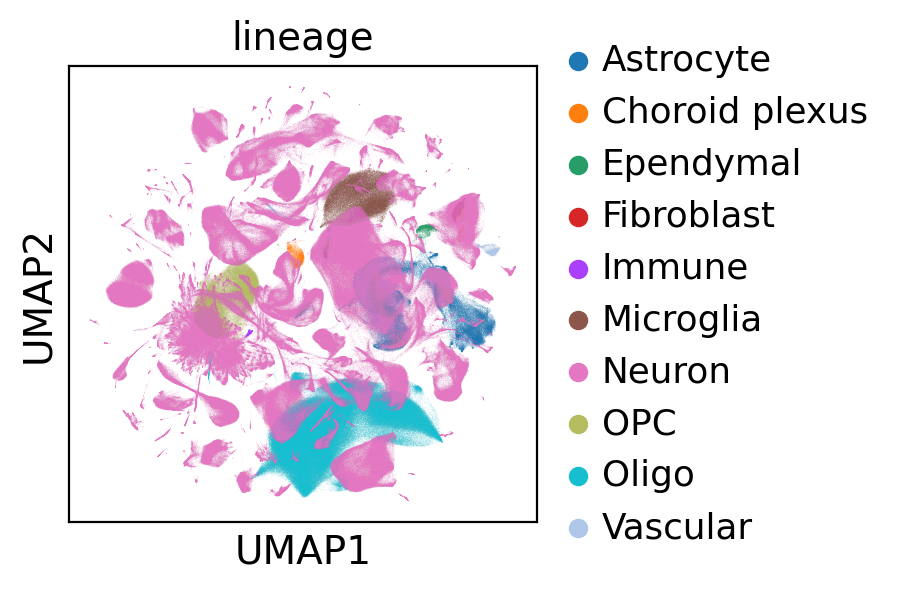

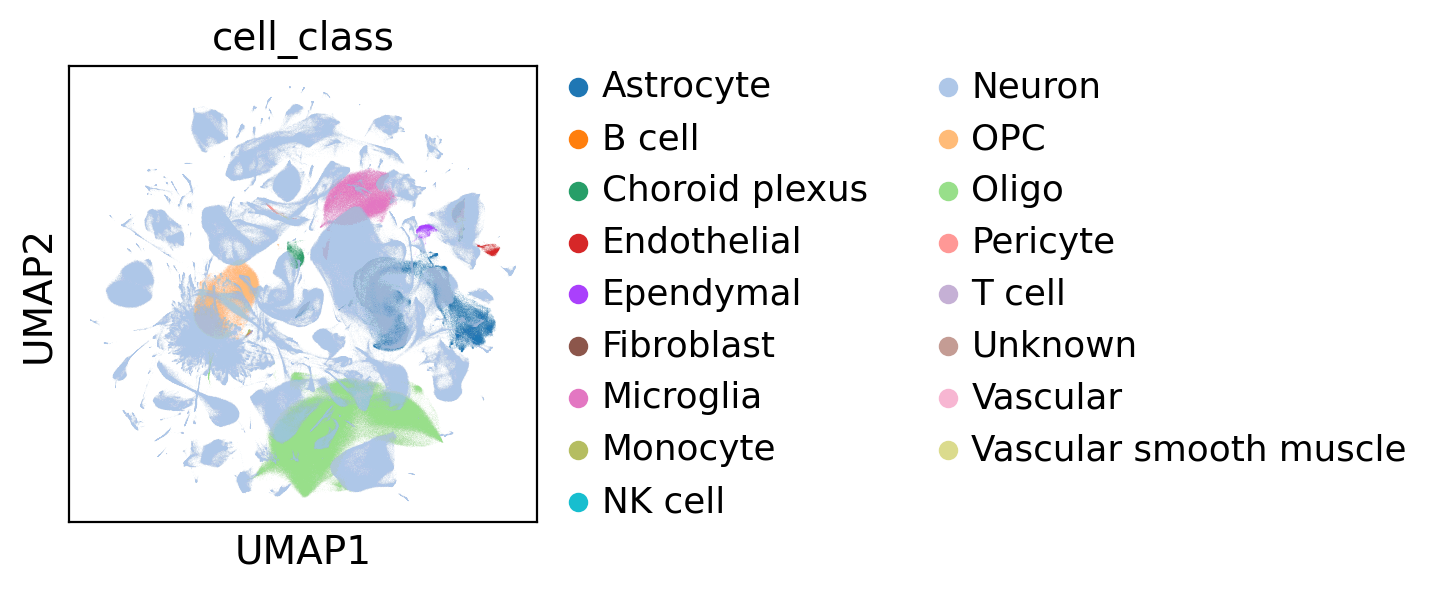

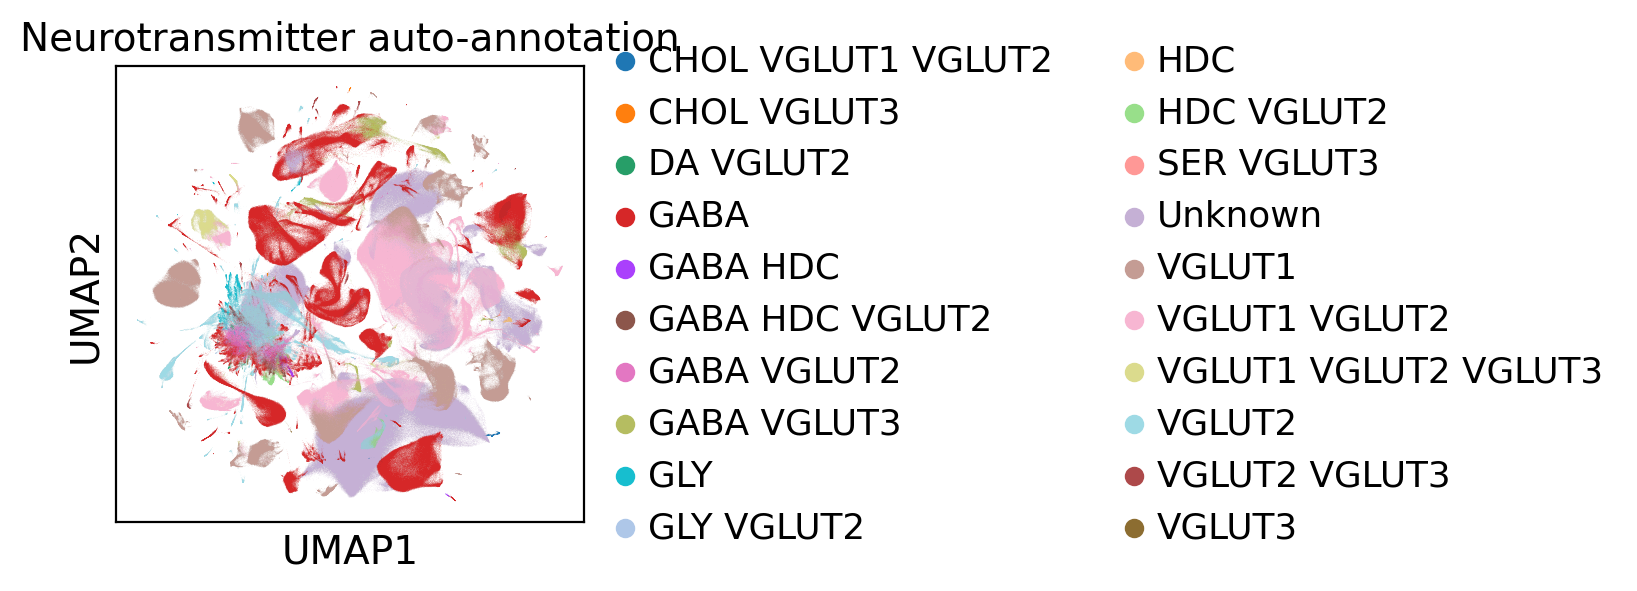

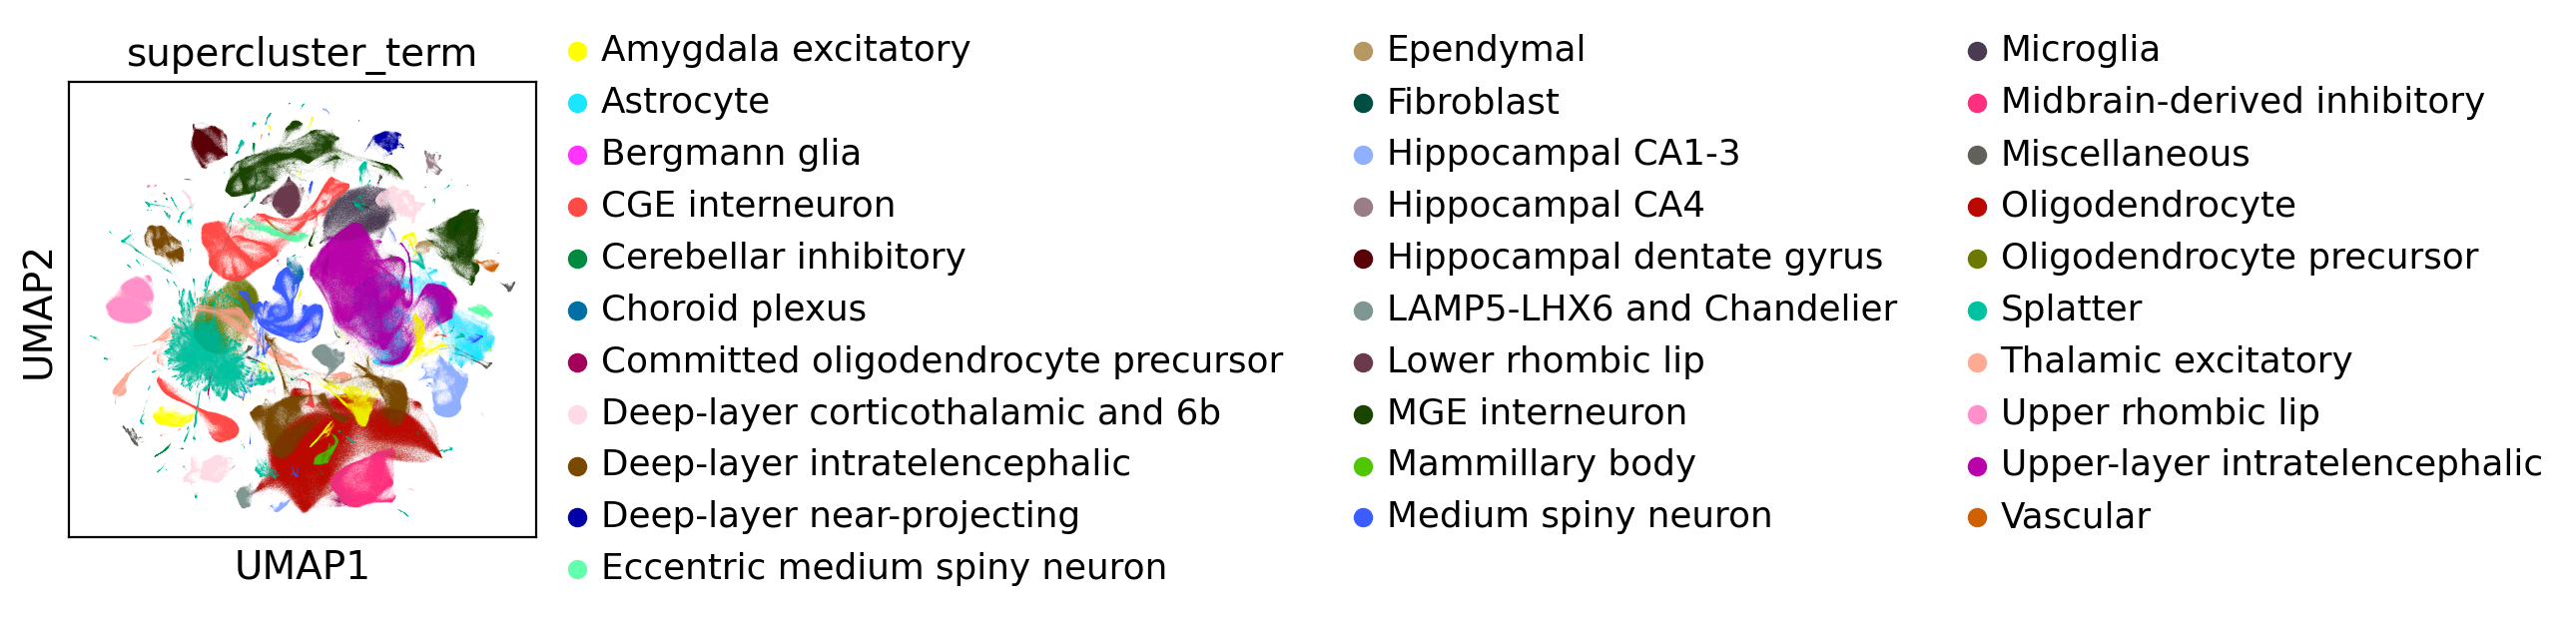

In [13]:
combined_adata.obsm['X_umap']=combined_adata.obsm['X_UMAP']

# Check if 'lineage' is categorical
if pd.api.types.is_categorical_dtype(combined_adata.obs['lineage']):
    combined_adata.obs['lineage'] = combined_adata.obs['lineage'].cat.remove_unused_categories()
    print("Unused categories removed from 'lineage'.")
    print("Remaining categories:", combined_adata.obs['lineage'].cat.categories.tolist())
else:
    print("'lineage' is not categorical — no action needed.")

sc.pl.umap(combined_adata,color='lineage')
sc.pl.umap(combined_adata,color='cell_class')
sc.pl.umap(combined_adata,color='Neurotransmitter auto-annotation')
sc.pl.umap(combined_adata,color='supercluster_term')

In [14]:
import re

# neuron-related clusters
neuron_terms = [
    'Upper-layer intratelencephalic',
    'Deep-layer intratelencephalic',
    'CGE interneuron',
    'MGE interneuron',
    'Medium spiny neuron',
    'Upper rhombic lip',
    'Midbrain-derived inhibitory',
    'Amygdala excitatory',
    'Thalamic excitatory',
    'Deep-layer corticothalamic and 6b',
    'Hippocampal CA1-3',
    'Hippocampal dentate gyrus',
    'Hippocampal CA4',
    'LAMP5-LHX6 and Chandelier',
    'Eccentric medium spiny neuron',
    'Deep-layer near-projecting',
    'Mammillary body',
    'Cerebellar inhibitory'
]

# Combine both annotation sources
combined_adata.obs['reanno'] = (
    combined_adata.obs['supercluster_term'].astype(str) + ' ' +
    combined_adata.obs['Neurotransmitter auto-annotation'].astype(str)
)

# Clean up text
combined_adata.obs['reanno'] = (
    combined_adata.obs['reanno']
    .str.replace(r'auto-annotation', '', regex=True)
    .str.replace(r'\bUnknown\b', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Add "Neuron" tag to neuron clusters (if missing)
mask_neuron = combined_adata.obs['supercluster_term'].isin(neuron_terms)
combined_adata.obs.loc[mask_neuron & ~combined_adata.obs['reanno'].str.contains(r'\bNeuron\b', case=False), 'reanno'] = (
    combined_adata.obs.loc[mask_neuron & ~combined_adata.obs['reanno'].str.contains(r'\bNeuron\b', case=False), 'reanno'] + ' Neuron'
)

# Ensure "Neuron" always comes before neurotransmitters
def reorder_neuron_labels(x):
    # If it's a neuron cluster
    if any(term in x for term in neuron_terms):
        # extract neurotransmitters
        neurotrans = re.findall(r'\b(GABA|VGLUT1|VGLUT2|VGLUT3|HDC|CHOL|GLY|SER|DA)\b', x)
        # remove them temporarily
        base = re.sub(r'\b(GABA|VGLUT1|VGLUT2|VGLUT3|HDC|CHOL|GLY|SER|DA)\b', '', x)
        base = re.sub(r'\s+', ' ', base).strip()
        # make sure "Neuron" appears only once
        base = re.sub(r'\bNeuron\b', '', base).strip()
        if neurotrans:
            return f"{base} Neuron {' '.join(neurotrans)}"
        else:
            return f"{base} Neuron"
    else:
        # non-neuron case → just clean spaces
        return re.sub(r'\s+', ' ', x).strip()

combined_adata.obs['reanno'] = combined_adata.obs['reanno'].apply(reorder_neuron_labels)

# Final polish: remove trailing spaces
combined_adata.obs['reanno'] = combined_adata.obs['reanno'].str.strip()

In [15]:
set(combined_adata.obs['reanno'])

{'Amygdala excitatory Neuron VGLUT1 VGLUT2',
 'Amygdala excitatory Neuron VGLUT2 VGLUT3',
 'Astrocyte',
 'Bergmann glia',
 'CGE interneuron Neuron GABA',
 'CGE interneuron Neuron GABA VGLUT3',
 'Cerebellar inhibitory Neuron GABA',
 'Cerebellar inhibitory Neuron GLY',
 'Choroid plexus',
 'Committed oligodendrocyte precursor',
 'Deep-layer corticothalamic and 6b Neuron VGLUT1',
 'Deep-layer corticothalamic and 6b Neuron VGLUT1 VGLUT2',
 'Deep-layer corticothalamic and 6b Neuron VGLUT1 VGLUT2 VGLUT3',
 'Deep-layer intratelencephalic Neuron VGLUT1',
 'Deep-layer intratelencephalic Neuron VGLUT1 VGLUT2',
 'Deep-layer intratelencephalic Neuron VGLUT1 VGLUT2 VGLUT3',
 'Deep-layer near-projecting Neuron VGLUT1',
 'Deep-layer near-projecting Neuron VGLUT1 VGLUT2',
 'Deep-layer near-projecting Neuron VGLUT1 VGLUT2 VGLUT3',
 'Eccentric medium spiny neuron Neuron GABA',
 'Ependymal',
 'Fibroblast',
 'Hippocampal CA1-3 Neuron VGLUT1',
 'Hippocampal CA1-3 Neuron VGLUT1 VGLUT2',
 'Hippocampal CA4 Neu

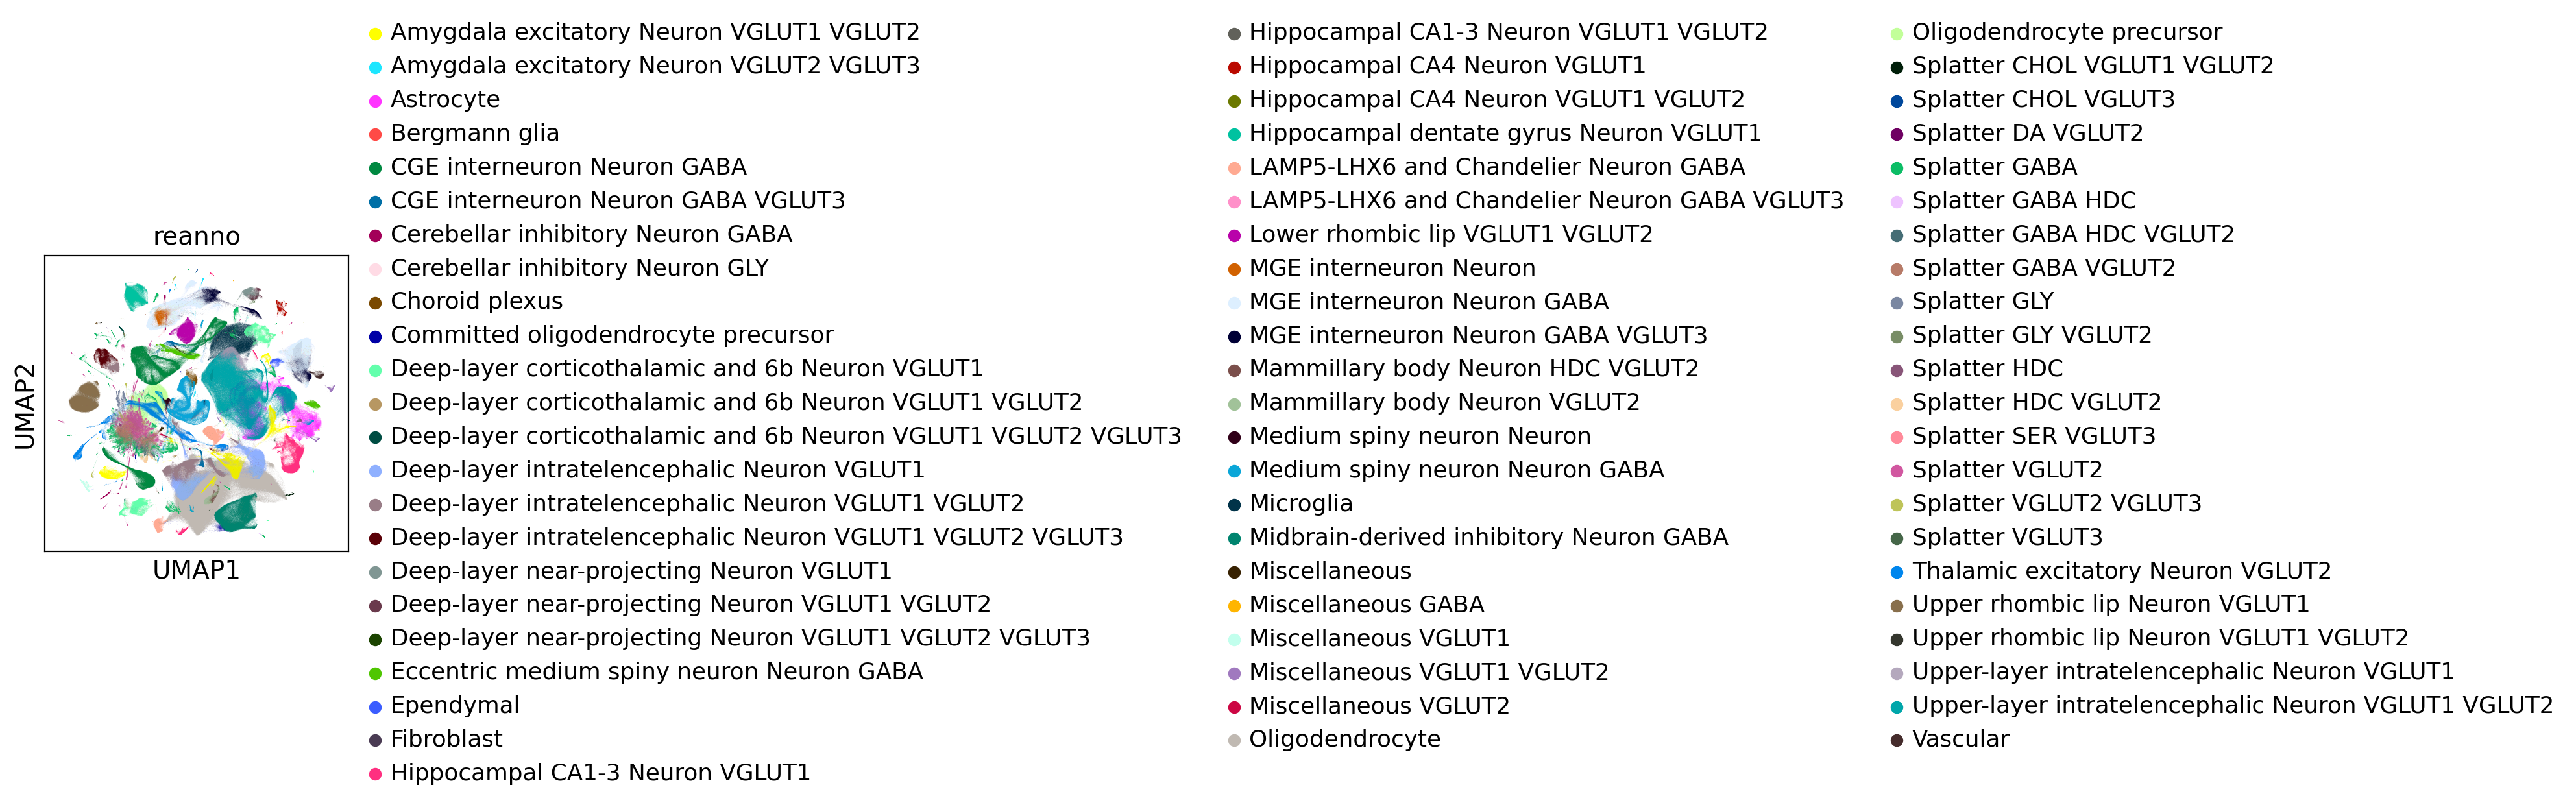

In [53]:
sc.pl.umap(combined_adata,color='reanno')

In [16]:
# Disable truncation and print full value_counts
with pd.option_context('display.max_rows', None):
    print(combined_adata.obs['reanno'].value_counts())

reanno
Oligodendrocyte                                                  490246
Upper-layer intratelencephalic Neuron VGLUT1 VGLUT2              399411
CGE interneuron Neuron GABA                                      209320
MGE interneuron Neuron GABA                                      164551
Astrocyte                                                        155025
Medium spiny neuron Neuron GABA                                  145305
Upper rhombic lip Neuron VGLUT1                                  136789
Midbrain-derived inhibitory Neuron GABA                          126782
Deep-layer intratelencephalic Neuron VGLUT1                      115762
Amygdala excitatory Neuron VGLUT1 VGLUT2                         107082
Oligodendrocyte precursor                                        105734
Splatter GABA                                                     98293
Microglia                                                         91838
Splatter VGLUT2                                          

In [17]:
# Rename the columns in preimplantation_adata.obs
combined_adata.obs.rename(
    columns={
        "development_stage": "stage",
        "total_UMIs": "nCount_RNA",
        "total_genes": "nFeature_RNA",
        "ROIGroupCoarse": "orig_anno",
        "ROIGroupFine": "orig_sub_anno",
        "dissection": "sample",
        "fraction_mitochondrial": "percent.mt",
        #"technology": "platform",
        #"experiment": "orig.ident"
    },
    inplace=True
)

# Verify the renamed columns
print("Renamed columns in adata.obs:")
print(combined_adata.obs.columns)

# Optionally inspect the first few rows of the updated .obs DataFrame
print("\nFirst few rows of updated .obs:")
print(combined_adata.obs.head())
combined_adata.obs["orig.ident"] = "Kimberly Siletti"
combined_adata.obs["orig.ident"] = combined_adata.obs["orig.ident"].astype("category")

Renamed columns in adata.obs:
Index(['ROIGroup', 'orig_anno', 'orig_sub_anno', 'roi',
       'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'assay_ontology_term_id', 'sex_ontology_term_id',
       'development_stage_ontology_term_id', 'donor_id', 'suspension_type',
       'sample', 'percent.mt', 'fraction_unspliced', 'cell_cycle_score',
       'nFeature_RNA', 'nCount_RNA', 'sample_id', 'supercluster_term',
       'cluster_id', 'subcluster_id', 'cell_type_ontology_term_id',
       'tissue_ontology_term_id', 'is_primary_data', 'tissue_type',
       'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'stage', 'observation_joinid', 'batch',
       'Supercluster', 'Class_auto_annotation',
       'Neurotransmitter auto-annotation', 'cell_class', 'lineage', 'reanno'],
      dtype='object')

First few rows of updated .obs:
                               ROIGroup     orig_anno orig_sub_anno       roi  \
CellID                      

In [18]:
# 定义要保留的列
columns_to_keep = [
    "stage", "nCount_RNA", "nFeature_RNA", "orig_anno", 
    "orig_sub_anno", "sample", "percent.mt", "reanno", 
    "orig.ident", "lineage"
]

# 检查哪些列实际存在于数据中
existing_columns = [col for col in columns_to_keep if col in combined_adata.obs.columns]
missing_columns = [col for col in columns_to_keep if col not in combined_adata.obs.columns]

print("存在的列:", existing_columns)
print("不存在的列:", missing_columns)

combined_adata=combined_adata.copy()
# 只保留存在的列
combined_adata.obs = combined_adata.obs[existing_columns]

print(f"筛选后的obs列: {list(combined_adata.obs.columns)}")
print(f"obs形状: {combined_adata.obs.shape}")

存在的列: ['stage', 'nCount_RNA', 'nFeature_RNA', 'orig_anno', 'orig_sub_anno', 'sample', 'percent.mt', 'reanno', 'orig.ident', 'lineage']
不存在的列: []
筛选后的obs列: ['stage', 'nCount_RNA', 'nFeature_RNA', 'orig_anno', 'orig_sub_anno', 'sample', 'percent.mt', 'reanno', 'orig.ident', 'lineage']
obs形状: (3369219, 10)


In [19]:
combined_adata.layers["counts"]=combined_adata.X.copy()

In [26]:
combined_adata.obs['lineage'].value_counts()

lineage
Neuron            2477203
Oligo              494896
Astrocyte          163066
OPC                105804
Microglia           91838
Vascular             9932
Choroid plexus       8631
Fibroblast           8214
Ependymal            5882
Immune               3753
Name: count, dtype: int64

In [20]:
combined_adata.write_h5ad(filename='/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251106_fetal_adult_merge_name_scdevelopment/data/human_adult_brain_clean.h5ad')